# Step 5: 개별종목 기반 Black-Litterman (시가총액 Prior)

## Step4와 차이점
| 항목 | Step4 (ETF) | Step5 (개별종목) |
|------|------------|----------------|
| 자산 유형 | 30개 ETF | 11섹터 × 5종목 = 55개 개별주식 |
| Prior w_mkt | 등가중(1/30) | **시가총액 가중** (CAPM 이론 정확) |
| 유니버스 | 고정 | **연간 동적 갱신** (시가총액 Top5 재선정) |
| 채권 | 포함 | 미포함 (순수 주식 포트폴리오) |

## 생존편향 한계 명시
- 후보 풀: 현재 S&P 500 구성종목 기반 → **과거 퇴출 종목 미포함**
- 완화책: 연도별 시가총액 재계산으로 Top5 동적 갱신
- 논문 서술: "생존편향 가능성이 존재하며 수익률이 과대평가될 수 있음"

## 참고 코드
- `김재천/black_litterman/test_01.py`: 유니버스 선정, 시가총액 추정
- `김재천/black_litterman/test_03.py`: 모멘텀/변동성 피처 빌드

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import warnings
import time
import pickle
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

BASE = Path('.')
DATA = BASE / 'data'
IMAGES = BASE / 'images'
CACHE = DATA / 'stock5_cache'
DATA.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)
CACHE.mkdir(exist_ok=True)

print('준비 완료')

준비 완료


## 셀 2: S&P 500 후보 풀 정의

**동적 후보 풀**: 현재 S&P 500 전체 종목을 Wikipedia에서 수집.  
매 리밸런싱 연도 기준으로 Wikipedia 변경이력 필터를 적용해 **당시 S&P 500에 있었던 종목만** 후보로 사용.

→ 고정 종목 풀(SECTOR_CANDIDATES) 없음 — 모든 종목이 동적으로 결정됨

In [17]:
import io
import requests

def fetch_sp500_snapshot(cache_path=None):
    """
    Wikipedia에서 현재 S&P 500 전체 종목 + GICS 섹터 수집
    반환: DataFrame with columns [ticker, sector]
    """
    cache_path = cache_path or (CACHE / 'sp500_snapshot.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print('S&P 500 전체 목록 수집 중...')
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))

    df = tables[0].copy()
    df.columns = [str(c).strip() for c in df.columns]
    ticker_col = next(c for c in df.columns if 'symbol' in c.lower() or 'ticker' in c.lower())
    sector_col = next(
        c for c in df.columns
        if 'gics sector' in c.lower() or ('sector' in c.lower() and 'sub' not in c.lower())
    )
    result = df[[ticker_col, sector_col]].rename(
        columns={ticker_col: 'ticker', sector_col: 'sector'}
    ).copy()
    result['ticker'] = result['ticker'].str.replace('.', '-', regex=False).str.strip()
    result = result.dropna().reset_index(drop=True)

    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    print(f'S&P 500 종목 {len(result)}개 수집 ({result["sector"].nunique()}개 섹터)')
    return result


TOP_N              = 5            # 섹터당 선정 종목 수
REBALANCE_FREQ     = 21           # 21거래일마다 BL 리밸런싱
UNIVERSE_UPDATE_FREQ = 252        # 252거래일(1년)마다 유니버스 갱신
ANALYSIS_START     = '2016-01-01'
PRICE_START        = '2013-01-01' # 모멘텀(252일) + 공분산(252일) 여유 기간
PRICE_END          = '2025-12-31'
COV_WIN            = 252
TAU                = 1 / 252      # Prior 불확실성
LAM                = 2.5          # 위험회피계수 λ


## 셀 2-B: S&P 500 변경이력으로 생존편향 완화

**핵심**: 현재 S&P 500 전체를 후보 풀로 사용하되, Wikipedia 변경이력으로
"분석 시점 이후에 편입된 종목"을 해당 시점의 후보 풀에서 제거.

예) 2016년 1월 기준 백테스트 시점:
- TSLA (2020년 편입) → 제거
- AVGO (2017년 편입) → 제거  
- AAPL, MSFT 등 2016년 이전 편입 종목 → 유지

**한계**: Wikipedia는 주요 변경만 기록 (완전하지 않음). 분석 기간 중 퇴출된
종목(파산·합병 등)은 복원 불가 → 이 한계를 명시적으로 논문에 기재 필요.


In [18]:
# ── Wikipedia S&P 500 변경이력 수집 ──────────────────────────────────────

def fetch_sp500_changes(cache_path=None):
    """Wikipedia S&P 500 변경이력 테이블 파싱
    반환: DataFrame with columns [date, added, removed]
    """
    cache_path = cache_path or (CACHE / 'sp500_changes.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print('Wikipedia S&P 500 변경이력 다운로드 중...')
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))
    raw = tables[1].copy()
    raw.columns = [str(c).strip() for c in raw.columns]
    date_col = raw.columns[0]
    def find_col(df, keywords):
        for c in df.columns:
            if any(k.lower() in str(c).lower() for k in keywords):
                return c
        return None
    added_col   = find_col(raw, ['added', 'add']) or raw.columns[1]
    removed_col = find_col(raw, ['removed', 'remove']) or raw.columns[3]
    changes = pd.DataFrame({
        'date':    pd.to_datetime(raw[date_col], errors='coerce'),
        'added':   raw[added_col].astype(str).str.strip().str.replace('.', '-', regex=False),
        'removed': raw[removed_col].astype(str).str.strip().str.replace('.', '-', regex=False),
    }).dropna(subset=['date'])
    changes['added']   = changes['added'].replace({'nan': None, 'NaN': None, '': None})
    changes['removed'] = changes['removed'].replace({'nan': None, 'NaN': None, '': None})
    changes = changes.sort_values('date').reset_index(drop=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(changes, f)
    print(f'변경이력 {len(changes)}건 로드')
    return changes


def filter_pool_by_date(snapshot_df, changes_df, target_date):
    """target_date 이후 S&P 500에 편입된 종목을 후보 풀에서 제거
    Returns: filtered_df (DataFrame), excluded (list)
    """
    target_dt   = pd.Timestamp(target_date)
    added_after = set(
        changes_df.loc[
            (changes_df['date'] > target_dt) & changes_df['added'].notna(), 'added'
        ].dropna()
    )
    filtered_df = snapshot_df[~snapshot_df['ticker'].isin(added_after)].reset_index(drop=True)
    excluded    = sorted(set(snapshot_df['ticker']) & added_after)
    return filtered_df, excluded


# ── 데이터 수집 실행 ──────────────────────────────────────────────────────
sp500_snapshot = fetch_sp500_snapshot()
sp500_changes  = fetch_sp500_changes()

# 2016-01-01 기준 필터링 테스트
filtered_2016, excluded_2016 = filter_pool_by_date(
    sp500_snapshot, sp500_changes, '2016-01-01')
print(f'\n2016-01-01 기준 필터링:')
print(f'  전체 풀: {len(sp500_snapshot)}개')
print(f'  필터링 후: {len(filtered_2016)}개')
print(f'  제외 종목 ({len(excluded_2016)}개, 일부): {excluded_2016[:8]}{"..." if len(excluded_2016) > 8 else ""}')
print(f'  → 이 종목들은 2016년 이후 S&P 500에 편입됨')

# ── 가격 수집 및 섹터 맵핑에 사용할 변수 도출 ─────────────────────────────
ALL_CANDIDATES   = list(sp500_snapshot['ticker'].unique())
TICKER_TO_SECTOR = dict(zip(sp500_snapshot['ticker'], sp500_snapshot['sector']))
print(f'다운로드 대상: {len(ALL_CANDIDATES)}개 종목')



2016-01-01 기준 필터링:
  전체 풀: 503개
  필터링 후: 342개
  제외 종목 (161개, 일부): ['ABNB', 'ACGL', 'AJG', 'ALB', 'ALGN', 'AMCR', 'AMD', 'ANET']...
  → 이 종목들은 2016년 이후 S&P 500에 편입됨
다운로드 대상: 503개 종목


## 셀 3: 가격 데이터 수집

In [19]:
prices_cache = CACHE / 'prices_all_candidates.pkl'

if prices_cache.exists():
    with open(prices_cache, 'rb') as f:
        prices_raw = pickle.load(f)
    print(f'캐시 로드: {prices_raw.shape}')
else:
    print(f'{len(ALL_CANDIDATES)}개 종목 가격 다운로드 중 (2013-2025)...')
    prices_raw = yf.download(
        ALL_CANDIDATES,
        start=PRICE_START,
        end=PRICE_END,
        auto_adjust=True,
        progress=True
    )['Close']
    with open(prices_cache, 'wb') as f:
        pickle.dump(prices_raw, f)
    print(f'저장 완료: {prices_raw.shape}')

# 결측이 10% 이상인 종목 제거
valid_mask = prices_raw.notna().mean() >= 0.90
prices = prices_raw.loc[:, valid_mask].ffill()

# 유효 종목 → TICKER_TO_SECTOR 업데이트
valid_tickers    = set(prices.columns)
TICKER_TO_SECTOR = {t: s for t, s in TICKER_TO_SECTOR.items() if t in valid_tickers}

# sp500_snapshot도 유효 종목으로 필터링
sp500_snapshot = sp500_snapshot[
    sp500_snapshot['ticker'].isin(valid_tickers)
].reset_index(drop=True)

print(f'\n유효 종목: {len(valid_tickers)}개')
print(f'기간: {prices.index[0].date()} ~ {prices.index[-1].date()}')
for s, grp in sp500_snapshot.groupby('sector'):
    avail = [t for t in grp['ticker'] if t in valid_tickers]
    print(f'  {s[:30]:30s}: {len(avail)}개 가용')


캐시 로드: (3269, 503)

유효 종목: 457개
기간: 2013-01-02 ~ 2025-12-30
  Communication Services        : 20개 가용
  Consumer Discretionary        : 45개 가용
  Consumer Staples              : 34개 가용
  Energy                        : 21개 가용
  Financials                    : 69개 가용
  Health Care                   : 55개 가용
  Industrials                   : 70개 가용
  Information Technology        : 61개 가용
  Materials                     : 24개 가용
  Real Estate                   : 29개 가용
  Utilities                     : 29개 가용


## 셀 4: 발행주식수 수집 (시가총액 추정용)

시가총액 = 주가 × 발행주식수
- 현재 발행주식수를 가져와 역사적 시가총액의 프록시로 사용
- 김재천의 estimate_historical_market_cap 방식 참고

In [20]:
shares_cache = CACHE / 'shares_outstanding.pkl'

def fetch_shares_outstanding(tickers, cache_path):
    """yfinance info에서 발행주식수 수집 (캐시 지원)"""
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            shares_dict = pickle.load(f)
    else:
        shares_dict = {}

    missing = [t for t in tickers if t not in shares_dict]
    if missing:
        print(f'{len(missing)}개 종목 주식수 조회 중...')
        for i, ticker in enumerate(missing):
            try:
                info = yf.Ticker(ticker).info
                s = info.get('sharesOutstanding') or info.get('impliedSharesOutstanding')
                shares_dict[ticker] = float(s) if s else None
            except Exception:
                shares_dict[ticker] = None
            if (i + 1) % 30 == 0:
                print(f'  {i+1}/{len(missing)} 완료')
                time.sleep(1)
        with open(cache_path, 'wb') as f:
            pickle.dump(shares_dict, f)
        print('저장 완료')
    else:
        print(f'캐시 로드: {len(shares_dict)}개')

    return shares_dict


shares_dict = fetch_shares_outstanding(list(valid_tickers), shares_cache)

n_ok = sum(1 for v in shares_dict.values() if v and v > 0)
print(f'\n주식수 조회 성공: {n_ok}/{len(valid_tickers)}')

# 시가총액 스냅샷 (최신 기준)
latest = prices.iloc[-1]
mcap_latest = {
    t: latest.get(t, np.nan) * (shares_dict.get(t) or np.nan)
    for t in valid_tickers
}
mcap_series = pd.Series(mcap_latest).dropna() / 1e9  # 단위: 십억달러

print(f'\n시가총액 상위 10종목 (최신 기준):')
print(mcap_series.nlargest(10).apply(lambda x: f'${x:.0f}B').to_string())

캐시 로드: 457개

주식수 조회 성공: 457/457

시가총액 상위 10종목 (최신 기준):
NVDA     $4557B
AAPL     $4005B
MSFT     $3612B
AMZN     $2501B
GOOGL    $1826B
GOOG     $1709B
TSLA     $1705B
AVGO     $1653B
META     $1461B
LLY       $963B


## 셀 5: 동적 유니버스 선정 함수

In [21]:
def select_universe_by_mcap(price_snap, shares_dict, pool_df, top_n=5):
    """
    특정 시점 가격 스냅샷 기준 섹터별 시가총액 상위 top_n 종목 선정

    Parameters
    ----------
    price_snap  : pd.Series   - 해당 시점 종가
    shares_dict : dict        - 종목별 발행주식수
    pool_df     : DataFrame   - 후보 풀 (columns: ticker, sector)
    top_n       : int         - 섹터당 선정 수

    Returns
    -------
    universe    : list        - 선정된 종목 리스트
    sector_map  : dict        - 섹터 → 선정 종목 매핑
    w_mkt       : pd.Series   - 시가총액 비중 (참고용)
    """
    sector_map = {}
    mcap_map   = {}

    for sector, grp in pool_df.groupby('sector'):
        avail = [
            t for t in grp['ticker']
            if t in price_snap.index
            and pd.notna(price_snap.get(t, np.nan))
            and shares_dict.get(t, 0) > 0
        ]
        if not avail:
            continue
        mcap     = {t: price_snap[t] * shares_dict[t] for t in avail}
        selected = sorted(mcap.items(), key=lambda x: x[1], reverse=True)[:top_n]
        sector_map[sector] = [t for t, _ in selected]
        for t, m in selected:
            mcap_map[t] = m

    universe   = [t for ts in sector_map.values() for t in ts]
    total_mcap = sum(mcap_map.values()) or 1
    w_mkt      = pd.Series({t: mcap_map[t] / total_mcap for t in universe})
    return universe, sector_map, w_mkt


# ── 최신 시점 테스트 ──────────────────────────────────────────────────────
latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, prices.index[-1])
test_universe, test_sector_map, test_w_mkt = select_universe_by_mcap(
    prices.iloc[-1], shares_dict, latest_pool, TOP_N
)
print(f'선정된 종목 수: {len(test_universe)} ({len(test_sector_map)}섹터)')
print(f'\n섹터별 선정 종목:')
for sector, tickers in sorted(test_sector_map.items()):
    weights = [f"{t}({test_w_mkt[t]*100:.1f}%)" for t in tickers]
    print(f'  {sector[:25]:25s}: {" | ".join(weights)}')


선정된 종목 수: 55 (11섹터)

섹터별 선정 종목:
  Communication Services   : GOOGL(5.0%) | GOOG(4.7%) | META(4.0%) | NFLX(1.1%) | TMUS(0.6%)
  Consumer Discretionary   : AMZN(6.9%) | TSLA(4.7%) | HD(0.9%) | MCD(0.6%) | BKNG(0.5%)
  Consumer Staples         : WMT(2.5%) | COST(1.1%) | PG(0.9%) | KO(0.8%) | PM(0.7%)
  Energy                   : XOM(1.4%) | CVX(0.8%) | COP(0.3%) | WMB(0.2%) | KMI(0.2%)
  Financials               : JPM(2.4%) | BRK-B(1.9%) | V(1.6%) | MA(1.4%) | BAC(1.1%)
  Health Care              : LLY(2.7%) | JNJ(1.4%) | ABBV(1.1%) | UNH(0.8%) | MRK(0.7%)
  Industrials              : GE(0.9%) | CAT(0.7%) | RTX(0.7%) | BA(0.5%) | UNP(0.4%)
  Information Technology   : NVDA(12.6%) | AAPL(11.0%) | MSFT(10.0%) | AVGO(4.6%) | ORCL(1.6%)
  Materials                : LIN(0.5%) | NEM(0.3%) | CRH(0.2%) | SHW(0.2%) | ECL(0.2%)
  Real Estate              : WELL(0.4%) | PLD(0.3%) | AMT(0.2%) | EQIX(0.2%) | SPG(0.2%)
  Utilities                : NEE(0.5%) | SO(0.3%) | DUK(0.3%) | AEP(0.2%) | SRE(0.2%

## 셀 6: BL 핵심 함수 (시가총액 Prior 포함)

In [ ]:
def compute_prior_risk_parity(cov, lam=2.5):
    """
    Risk Parity Prior: π = λΣw_rp
    Equal Risk Contribution (ERC): RC_i = w_i × (Σw)_i / σ_p → 모든 i 동일
    Maillard, Roncalli & Teiletche (2010) JoPM
    채권·주식 혼합 포트폴리오에서 시가총액 불가 시 사용
    """
    n = cov.shape[0]
    sigma = np.sqrt(np.diag(cov))
    # 역변동성 초기값 (ERC 근사)
    w0 = (1.0 / sigma) / (1.0 / sigma).sum()

    def erc_objective(w): # 모든 자산이 포트폴리오 전체 위험에 동일한 비율로 기여하도록 만드는 투자 비중을 찾음
        port_var = float(w @ cov @ w)
        if port_var < 1e-12:
            return 1e10
        rc = w * (cov @ w) / np.sqrt(port_var)
        target = np.sqrt(port_var) / n
        return float(np.sum((rc - target) ** 2))

    res = minimize(erc_objective, w0, method='SLSQP',
                   bounds=[(1e-4, 1.0)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
                   options={'ftol': 1e-10, 'maxiter': 1000})

    w_rp = np.clip(res.x if res.success else w0, 0, 1)
    w_rp /= w_rp.sum() # 비중 정규화(찾아낸 비중의 합이 100%가 되도록 맞춤)
    return pd.Series(lam * cov @ w_rp, index=range(n)) # CAPM의 역최적화 공식을 사용하여 risk parity 비중을 합리화해주는 시장 수익률을 최종적으로 뽑아냄


def compute_momentum_Q(prices_window, windows=(126, 189, 252)):
    """6/9/12개월 연환산 로그 수익률 평균 (Lee & Bae 2024) — 전 자산 공통"""
    log_p = np.log(prices_window)
    qs = []
    for w in windows:
        if len(log_p) > w:
            ret = (log_p.iloc[-1] - log_p.iloc[-(w+1)]) / w * 252
            qs.append(ret)
    if not qs:
        return pd.Series(0.0, index=prices_window.columns)
    return pd.concat(qs, axis=1).mean(axis=1)


def compute_omega_idzorek(Q, cov, tau=1/252, c_min=0.10, c_max=0.90):
    """횡단면 z-score → Idzorek(2004) Omega (방향 + 크기 반영)"""
    q = Q.values
    z = (q - q.mean()) / (q.std() + 1e-8)
    sig = 1.0 / (1.0 + np.exp(-np.abs(z)))
    confidence = c_min + (c_max - c_min) * (sig - 0.5) / 0.5
    confidence = np.clip(confidence, c_min, c_max)
    diag = np.array([((1 - c) / c) * tau * cov[i, i] for i, c in enumerate(confidence)])
    return np.diag(diag), confidence


def black_litterman(pi, cov, Q, omega, tau=1/252):
    """BL 사후 기대수익률 (절대적 뷰, P = Identity)"""
    n = len(pi)
    P = np.eye(n)
    tau_cov_inv = np.linalg.inv(tau * cov + np.eye(n) * 1e-8)
    omega_inv   = np.linalg.inv(omega   + np.eye(n) * 1e-8)
    precision = tau_cov_inv + P.T @ omega_inv @ P
    rhs = tau_cov_inv @ pi.values + P.T @ omega_inv @ Q.values
    mu_bl   = np.linalg.solve(precision + np.eye(n) * 1e-8, rhs)
    sigma_bl = cov + np.linalg.inv(precision + np.eye(n) * 1e-8)
    return pd.Series(mu_bl, index=Q.index), sigma_bl


def mvo_optimize_unified(mu, cov, gamma, equity_tickers, bond_tickers,
                          max_equity_weight, max_sector, sector_map,
                          max_bond_total, max_single_bond):
    """
    통합 MVO: 주식 + 채권/대안 ETF
    주식: 섹터 집중도 제약 + 개별 비중 상한
    채권: 전체 비중 상한 + 개별 상한
    """
    all_tickers = list(equity_tickers) + list(bond_tickers)
    n = len(all_tickers)
    mu_arr = mu.reindex(all_tickers).fillna(0).values

    eq_idx   = list(range(len(equity_tickers)))
    bond_idx = list(range(len(equity_tickers), n))

    def neg_utility(w):
        return -(w @ mu_arr - (gamma / 2) * w @ cov @ w)

    constraints = [
        {'type': 'eq',   'fun': lambda w: w.sum() - 1.0},
        {'type': 'ineq', 'fun': lambda w: max_bond_total - w[bond_idx].sum()},
    ]
    if sector_map:
        for sector, s_tickers in sector_map.items():
            idx = [eq_idx[list(equity_tickers).index(t)]
                   for t in s_tickers if t in list(equity_tickers)]
            if idx:
                constraints.append({
                    'type': 'ineq',
                    'fun': lambda w, i=idx: max_sector - sum(w[j] for j in i)
                })

    bounds = ([(0.0, max_equity_weight)] * len(equity_tickers) +
              [(0.0, max_single_bond)]   * len(bond_tickers))

    res = minimize(neg_utility, np.ones(n) / n, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 1000})

    w = np.clip(res.x if res.success else np.ones(n)/n, 0, 1)
    return pd.Series(w / w.sum(), index=all_tickers)


print('BL 함수 정의 완료 (Risk Parity Prior + 통합 MVO)')

BL 함수 정의 완료 (Risk Parity Prior + 통합 MVO)


## 셀 7: 리스크 프로파일 + 통합 BL 설계

### 설계 전환 이유 (회의 결정)
- 모멘텀 Q는 주식뿐 아니라 채권·대안 ETF에도 동일하게 계산 가능
- → 굳이 2단계로 분리하지 않고, **모든 자산을 단일 BL로 통합**
- Prior: 채권 포함 시 시가총액 가중 불가 → **Risk Parity Prior** 사용

### Risk Parity Prior 수식 (Maillard et al. 2010)
```
목표: RC_i = w_i × (Σw)_i / σ_p  →  모든 i에 대해 동일
π = λΣw_rp  (w_rp: ERC 최적화 결과)
```

| Prior | 수식 | 적용 자산 | 근거 |
|-------|------|---------|------|
| ~~시가총액~~ | π = λΣw_mkt | 주식만 | He & Litterman (1992) |
| **리스크패리티** | **π = λΣw_rp** | **주식+채권+대안** | Maillard et al. (2010) |

### 주의: 리스크패리티 Prior의 한계
- 저변동성 자산(채권, GLD)에 높은 비중 → π가 채권에 주식보다 높은 implied return 부여 가능
- **해결**: MVO 단계에서 프로파일별 `max_bond_total` 상한으로 보정

### 통합 BL 구조
```
combined_universe = equity_stocks(동적) ∪ BOND_TICKERS(고정)
  ↓
Risk Parity Prior (π) 계산
  ↓
Momentum Q — 전 자산 동일 공식
  ↓
Idzorek Z-score Omega
  ↓
단일 BL → μ_BL, Σ_BL
  ↓
MVO (프로파일별 max_equity_weight + max_bond_total 제약)
```

In [23]:
# ── 채권/대안 ETF (통합 BL에 함께 포함) ───────────────────────────────────
# 근거: 모멘텀 Q는 ETF에도 동일하게 적용 가능 (팀 회의 결정 + Asness et al. 2013)
# TLT: 장기국채 20Y+ (flight-to-safety)
# SHY: 단기국채 1-3Y (현금성 안전자산)
# TIP: 물가연동채 (인플레 헤지)
# AGG: 미국 종합채권 (광의 채권 시장 노출)
# GLD: 금 (지정학 위기·통화 약세 헤지)
# DBC: 원자재 (인플레·공급 충격 헤지)
BOND_TICKERS = ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']

# ── 리스크 프로파일 ──────────────────────────────────────────────────────
# max_equity_weight: 개별 주식 비중 상한
# max_sector      : 섹터 집중도 상한 (주식 섹터만 적용)
# max_bond_total  : 채권+대안 전체 비중 상한
# max_single_bond : 채권/대안 개별 상한
PROFILES = {
    'Aggressive':   {'gamma': 2, 'max_equity_weight': 0.15, 'max_sector': 0.50,
                     'max_bond_total': 0.20, 'max_single_bond': 0.12},
    'Neutral':      {'gamma': 5, 'max_equity_weight': 0.08, 'max_sector': 0.35,
                     'max_bond_total': 0.35, 'max_single_bond': 0.12},
    'Conservative': {'gamma': 8, 'max_equity_weight': 0.05, 'max_sector': 0.25,
                     'max_bond_total': 0.55, 'max_single_bond': 0.20},
}

print('프로파일:')
print(f'{"":15s} {"γ":>4s} {"max_eq_w":>9s} {"max_sec":>9s} {"max_bond":>9s}')
for name, p in PROFILES.items():
    print(f'{name:15s} {p["gamma"]:>4} {p["max_equity_weight"]:>9.0%} '
          f'{p["max_sector"]:>9.0%} {p["max_bond_total"]:>9.0%}')
print(f'\n채권/대안 ETF: {BOND_TICKERS}')


프로파일:
                   γ  max_eq_w   max_sec  max_bond
Aggressive         2       15%       50%       20%
Neutral            5        8%       35%       35%
Conservative       8        5%       25%       55%

채권/대안 ETF: ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']


## 셀 7-B: 채권/대안 ETF 데이터 수집 (통합 BL용)

TLT·SHY·TIP·GLD를 주식과 **같은 BL 프레임**에 통합.
모멘텀 Q와 Omega를 주식과 동일한 방식으로 계산.

In [24]:
bond_cache = CACHE / 'bond_prices.pkl'

if bond_cache.exists():
    with open(bond_cache, 'rb') as f:
        bond_prices = pickle.load(f)
    print(f'채권 데이터 로드: {bond_prices.shape} (캐시)')
else:
    print('채권 ETF 데이터 다운로드 중...')
    raw = yf.download(BOND_TICKERS, start=PRICE_START, end=PRICE_END,
                      auto_adjust=True)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame()
    bond_prices = raw[BOND_TICKERS].dropna(how='all').ffill()
    with open(bond_cache, 'wb') as f:
        pickle.dump(bond_prices, f)
    print(f'채권 데이터 저장: {bond_prices.shape}')

print(f'기간: {bond_prices.index[0].date()} ~ {bond_prices.index[-1].date()}')
print(f'수집 자산: {list(bond_prices.columns)}')

채권 데이터 로드: (3269, 6) (캐시)
기간: 2013-01-02 ~ 2025-12-30
수집 자산: ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']


## 셀 8: 단일 기간 검증 (최신 시점)

In [25]:
# 최신 시점 기준 BL 1회 실행 (주식 + 채권/대안 통합)
end_date = prices.index[-1]

# 통합 유니버스 구성
latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, end_date)
eq_univ, eq_sector_map, _ = select_universe_by_mcap(
    prices.iloc[-1], shares_dict, latest_pool, TOP_N
)
combined_univ = list(eq_univ) + [b for b in BOND_TICKERS if b not in eq_univ]

# prices_combined 구성 (주식 + 채권)
prices_combined = prices.copy()
for bt in BOND_TICKERS:
    if bt in bond_prices.columns:
        prices_combined[bt] = bond_prices[bt]
prices_combined = prices_combined.ffill()

prices_win = prices_combined.loc[:end_date, combined_univ]
recent_252 = prices_win.iloc[-COV_WIN:]
log_ret_252 = np.log(recent_252 / recent_252.shift(1)).dropna()

# 공분산 (Ledoit-Wolf)
lw = LedoitWolf()
lw.fit(log_ret_252)
cov_val = lw.covariance_ * 252

# Risk Parity Prior (전 자산 공통)
pi_raw = compute_prior_risk_parity(cov_val, LAM)
pi_val = pd.Series(pi_raw.values, index=combined_univ)

# Q — 6/9/12개월 모멘텀 (전 자산 동일 공식, Asness et al. 2013)
Q_val = compute_momentum_Q(prices_win, (126, 189, 252))

# Omega
omega_val, conf = compute_omega_idzorek(Q_val, cov_val, TAU)

# BL 사후
mu_bl, sigma_bl = black_litterman(pi_val, cov_val, Q_val, omega_val, TAU)

# 결과 DataFrame
asset_type = {t: 'Bond/Alt' if t in BOND_TICKERS else TICKER_TO_SECTOR.get(t, 'Equity')
              for t in combined_univ}
bl_result = pd.DataFrame({
    'Prior_π': pi_val,
    'Q_모멘텀': Q_val,
    'μ_BL': mu_bl,
    '신뢰도': pd.Series(conf, index=combined_univ),
    '자산유형': pd.Series(asset_type),
})
print(f'=== BL 단일 기간 결과 ({end_date.date()}) ===')
print(f'유니버스: 주식 {len(eq_univ)}개 + 채권/대안 {len(BOND_TICKERS)}개 = {len(combined_univ)}개')
print()
print(bl_result.sort_values('μ_BL', ascending=False).to_string(float_format=lambda x: f'{x:.3f}'))


=== BL 단일 기간 결과 (2025-12-30) ===
유니버스: 주식 55개 + 채권/대안 6개 = 61개

       Prior_π  Q_모멘텀   μ_BL   신뢰도                    자산유형
NEM      0.032  1.040  0.901 0.831               Materials
GOOGL    0.027  0.862  0.753 0.773  Communication Services
GOOG     0.028  0.854  0.744 0.769  Communication Services
TSLA     0.064  0.525  0.690 0.539  Consumer Discretionary
AVGO     0.044  0.640  0.689 0.641  Information Technology
CAT      0.035  0.674  0.537 0.667             Industrials
ORCL     0.040  0.139  0.474 0.166  Information Technology
NVDA     0.041  0.476  0.460 0.487  Information Technology
GE       0.039  0.552  0.400 0.565             Industrials
GLD      0.009  0.483  0.365 0.494                Bond/Alt
LLY      0.032  0.449  0.359 0.456             Health Care
CRH      0.040  0.458  0.338 0.466               Materials
RTX      0.026  0.477  0.323 0.488             Industrials
JPM      0.034  0.310  0.287 0.279              Financials
BA       0.040  0.201  0.261 0.124             Indu

## 셀 8-B: 모멘텀 윈도우 최적화 EDA

**자산별 최적 모멘텀 윈도우를 IC(Information Coefficient) 분석으로 결정**

- IC = Spearman 상관계수(모멘텀, 미래 21일 수익률)
- t-검정: IC 분포의 귀무가설 H₀: IC = 0
- 팀장님 제안: "자산별로 모멘텀이 달라지는 애들이 있을 거에요 — EDA로 확인해보자" 

In [ ]:
from scipy.stats import spearmanr, ttest_1samp
import warnings
warnings.filterwarnings('ignore')

WINDOWS_EDA   = [21, 42, 63, 126, 189, 252]  # 1M, 2M, 3M, 6M, 9M, 12M
FORWARD_DAYS  = 21                             # 미래 수익률 예측 기간

def compute_rolling_ic(prices_df, window, forward_days=FORWARD_DAYS):
    """
    횡단면 IC(정보계수) 시계열 계산
    IC_t = Spearman(모멘텀_t, 수익률_{t+forward_days})
    """
    ic_list = []
    momentum = prices_df.pct_change(window)
    future_r  = prices_df.pct_change(forward_days).shift(-forward_days)

    for t_idx in range(window, len(prices_df) - forward_days):
        mom_row = momentum.iloc[t_idx].dropna()
        fut_row = future_r.iloc[t_idx].reindex(mom_row.index).dropna()
        common  = mom_row.index.intersection(fut_row.index)
        if len(common) < 5:
            continue
        ic, _ = spearmanr(mom_row[common], fut_row[common])
        ic_list.append({'date': prices_df.index[t_idx], 'ic': ic})

    return pd.DataFrame(ic_list).set_index('date') if ic_list else pd.DataFrame()


# ── 전체 가격 데이터 결합 (주식 + 채권) ─────────────────────────────
# bond_prices는 앞 셀에서 이미 로드됨
prices_all = prices.reindex(
    prices.index.union(bond_prices.index)
).combine_first(bond_prices)
prices_all = prices_all.sort_index().ffill()

# ── 윈도우별 IC 계산 ──────────────────────────────────────────────
print("IC 계산 중 (시간 소요)...")
ic_results = {}
for w in WINDOWS_EDA:
    df = compute_rolling_ic(prices_all, w)
    if not df.empty:
        ic_results[w] = df
        mean_ic  = df['ic'].mean()
        t_stat, p_val = ttest_1samp(df['ic'].dropna(), 0)
        sig = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else ''))
        print(f"  윈도우 {w:3d}일 | mean IC={mean_ic:+.4f} | t={t_stat:+.2f} | p={p_val:.4f} {sig}")

# ── 자산별 최적 윈도우 (개별 IC 분석) ─────────────────────────────
print("\n자산별 최적 윈도우 탐색...")
asset_best = {}
# test_universe: 셀 5에서 정의된 최신 시점 유니버스 (55개 주식)
SAMPLE_TICKERS = test_universe[:20] + BOND_TICKERS  # 속도를 위해 샘플링

for ticker in SAMPLE_TICKERS:
    if ticker not in prices_all.columns:
        continue
    p_series = prices_all[[ticker]].dropna()
    ic_per_w  = {}
    for w in WINDOWS_EDA:
        df_tmp = compute_rolling_ic(p_series, w)
        if not df_tmp.empty and len(df_tmp) >= 30:
            mean_ic  = df_tmp['ic'].mean()
            t_stat, p_val = ttest_1samp(df_tmp['ic'].dropna(), 0)
            ic_per_w[w] = {'mean_ic': mean_ic, 'abs_ic': abs(mean_ic), 't': t_stat, 'p': p_val}
    if ic_per_w:
        best_w = max(ic_per_w, key=lambda w: ic_per_w[w]['abs_ic'])
        asset_best[ticker] = best_w

# ── 결과 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) 윈도우별 평균 IC 바차트
ax = axes[0]
window_labels = [str(w) for w in WINDOWS_EDA]
mean_ics = [ic_results[w]['ic'].mean() if w in ic_results else 0 for w in WINDOWS_EDA]
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in mean_ics]
ax.bar(window_labels, mean_ics, color=colors_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('윈도우별 평균 IC (횡단면)')
ax.set_xlabel('모멘텀 윈도우 (거래일)')
ax.set_ylabel('Mean IC')
ax.grid(True, alpha=0.3, axis='y')

# 2) 자산별 최적 윈도우 분포
ax2 = axes[1]
if asset_best:
    best_counts = pd.Series(asset_best).value_counts().sort_index()
    ax2.bar([str(w) for w in best_counts.index], best_counts.values,
            color='#3498db', edgecolor='white')
    ax2.set_title('자산별 최적 윈도우 분포')
    ax2.set_xlabel('최적 모멘텀 윈도우 (거래일)')
    ax2.set_ylabel('자산 수')
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(IMAGES / 'step5_eda_momentum_windows.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: images/step5_eda_momentum_windows.png")

# ── 최적 윈도우 결정 ──────────────────────────────────────────────
# 전체 평균 IC 기준 Top 3 윈도우 선정
ranked = sorted(ic_results.keys(),
                key=lambda w: abs(ic_results[w]['ic'].mean()), reverse=True)
OPTIMAL_WINDOWS = tuple(sorted(ranked[:3]))
print(f"\n✓ 선정된 최적 모멘텀 윈도우: {OPTIMAL_WINDOWS} (이후 백테스트에서 사용)")

## 셀 9: Walk-Forward 백테스트

- **21거래일**: BL 기반 비중 리밸런싱
- **252거래일(1년)**: 유니버스 갱신 (시가총액 Top5 재선정)
- Look-ahead bias 없음: 각 시점에서 과거 데이터만 사용

In [26]:
analysis_days = prices_combined.loc[ANALYSIS_START:].index
n_days = len(analysis_days)

# ── 초기 유니버스 ─────────────────────────────────────────────────────────
init_date  = analysis_days[0]
init_pool, init_excluded = filter_pool_by_date(sp500_snapshot, sp500_changes, init_date)
start_snap = prices.loc[init_date]
current_eq_univ, current_sector_map, _ = select_universe_by_mcap(
    start_snap, shares_dict, init_pool, TOP_N
)
n_eq = len(current_eq_univ)

# 통합 유니버스: 주식 + 채권/대안 ETF (고정)
def build_combined_universe(eq_univ, bond_tickers):
    return list(eq_univ) + [b for b in bond_tickers if b not in eq_univ]

current_universe = build_combined_universe(current_eq_univ, BOND_TICKERS)
n_all = len(current_universe)

# 초기 비중: 등가중
current_weights = {
    p: pd.Series(1.0 / n_all, index=current_universe) for p in PROFILES
}
current_weights['EqualWeight'] = pd.Series(1.0 / n_all, index=current_universe)

port_values   = {p: [1.0] for p in list(PROFILES.keys()) + ['EqualWeight']}
rebalance_log = []

print(f'분석 기간: {analysis_days[0].date()} ~ {analysis_days[-1].date()} ({n_days}거래일)')
print(f'초기 유니버스: 주식 {n_eq}종목 + 채권/대안 {len(BOND_TICKERS)}개 = {n_all}개')
print(f'Prior: Risk Parity (Maillard et al. 2010) | Omega: Idzorek Z-score\n')

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]

    # ── 일별 수익률 ───────────────────────────────────────────────────────
    ret = {}
    for t in current_universe:
        if t in prices_combined.columns:
            p0 = prices_combined.at[prev_date, t] if prev_date in prices_combined.index else np.nan
            p1 = prices_combined.at[date, t]      if date      in prices_combined.index else np.nan
            ret[t] = (p1 / p0 - 1) if (pd.notna(p0) and pd.notna(p1) and p0 > 0) else 0.0
        else:
            ret[t] = 0.0

    # ── 포트폴리오 가치 업데이트 ──────────────────────────────────────────
    for p in list(PROFILES.keys()) + ['EqualWeight']:
        w = current_weights[p]
        port_ret = sum(w.get(t, 0.0) * ret.get(t, 0.0) for t in current_universe)
        port_values[p].append(port_values[p][-1] * (1 + port_ret))

    # ── 연간 유니버스 갱신 (252일마다) ────────────────────────────────────
    if i % UNIVERSE_UPDATE_FREQ == 0:
        year_pool, year_excl = filter_pool_by_date(sp500_snapshot, sp500_changes, date)
        snap = prices.loc[date]
        new_eq_univ, new_sector_map, _ = select_universe_by_mcap(
            snap, shares_dict, year_pool, TOP_N
        )
        current_eq_univ    = new_eq_univ
        current_sector_map = new_sector_map
        current_universe   = build_combined_universe(current_eq_univ, BOND_TICKERS)
        n_all = len(current_universe)
        for p in list(PROFILES.keys()) + ['EqualWeight']:
            current_weights[p] = pd.Series(1.0 / n_all, index=current_universe)
        excl_str = f' (미편입 제외 {len(year_excl)}종목)' if year_excl else ''
        print(f'  [{date.date()}] 유니버스 갱신: 주식 {len(current_eq_univ)}+채권 {len(BOND_TICKERS)}{excl_str}')

    # ── 21일마다 BL 리밸런싱 ──────────────────────────────────────────────
    if i % REBALANCE_FREQ == 0:
        prices_win = prices_combined.loc[:date, current_universe]
        if len(prices_win) < COV_WIN + 253:
            continue

        recent = prices_win.iloc[-COV_WIN:]
        log_r  = np.log(recent / recent.shift(1)).dropna()
        if log_r.shape[0] < 60:
            continue

        lw = LedoitWolf()
        lw.fit(log_r)
        cov = lw.covariance_ * 252

        # Risk Parity Prior (채권 포함 전체 유니버스)
        pi_raw = compute_prior_risk_parity(cov, LAM)
        pi = pd.Series(pi_raw.values, index=current_universe)

        # Momentum Q (전 자산 동일 공식, Asness et al. 2013)
        Q = compute_momentum_Q(prices_win, (126, 189, 252))
        Q = Q.reindex(current_universe).fillna(0)

        omega, _ = compute_omega_idzorek(Q, cov, TAU)
        mu_bl, sigma_bl = black_litterman(pi, cov, Q, omega, TAU)

        for p, prof in PROFILES.items():
            w_new = mvo_optimize_unified(
                mu_bl, sigma_bl, prof['gamma'],
                equity_tickers    = list(current_eq_univ),
                bond_tickers      = BOND_TICKERS,
                max_equity_weight = prof['max_equity_weight'],
                max_sector        = prof['max_sector'],
                sector_map        = current_sector_map,
                max_bond_total    = prof['max_bond_total'],
                max_single_bond   = prof['max_single_bond'],
            )
            current_weights[p] = w_new

        # EqualWeight: 등가중 (편의상 BL 미적용)
        current_weights['EqualWeight'] = pd.Series(1.0 / n_all, index=current_universe)
        rebalance_log.append({'date': date, 'n_assets': n_all})

print(f'\n백테스트 완료! 총 리밸런싱: {len(rebalance_log)}회')
if rebalance_log:
    last_w = current_weights.get('Neutral', pd.Series())
    bond_alloc = last_w.reindex(BOND_TICKERS).fillna(0).sum()
    print(f'최근 Neutral 채권/대안 비중: {bond_alloc:.1%}')


분석 기간: 2016-01-04 ~ 2025-12-30 (2513거래일)
초기 유니버스: 주식 55종목 + 채권/대안 6개 = 61개
Prior: Risk Parity (Maillard et al. 2010) | Omega: Idzorek Z-score



  [2017-01-03] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 103종목)
  [2018-01-03] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 83종목)
  [2019-01-04] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 74종목)
  [2020-01-06] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 58종목)
  [2021-01-05] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 50종목)
  [2022-01-04] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 40종목)
  [2023-01-05] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 28종목)
  [2024-01-08] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 18종목)
  [2025-01-08] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 10종목)

백테스트 완료! 총 리밸런싱: 119회
최근 Neutral 채권/대안 비중: 12.0%


## 셀 10: 성능 지표 계산

In [28]:
def compute_metrics(values, dates_list):
    vals = np.array(values)
    rets = np.diff(vals) / vals[:-1]
    n_years = (pd.Timestamp(dates_list[-1]) - pd.Timestamp(dates_list[0])).days / 365.25
    total_ret = vals[-1] / vals[0] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    running_max = np.maximum.accumulate(vals)
    mdd = ((vals - running_max) / running_max).min()
    down = rets[rets < 0]
    sortino = ann_ret / (down.std() * np.sqrt(252)) if len(down) > 0 else 0
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    return {
        'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'mdd': mdd, 'sortino': sortino, 'calmar': calmar, 'total_return': total_ret
    }


dates = list(analysis_days)
metrics = {}
for p in list(PROFILES.keys()) + ['EqualWeight']:
    metrics[p] = compute_metrics(port_values[p], dates)

# SPY B&H 벤치마크
spy_cache = CACHE / 'spy_prices.pkl'
if spy_cache.exists():
    with open(spy_cache, 'rb') as f:
        spy_raw = pickle.load(f)
else:
    spy_raw = yf.download('SPY', start=ANALYSIS_START, end=PRICE_END, auto_adjust=True)['Close'].squeeze()
    with open(spy_cache, 'wb') as f:
        pickle.dump(spy_raw, f)

spy_aligned = spy_raw.loc[ANALYSIS_START:]
spy_norm = (spy_aligned / spy_aligned.iloc[0]).values
metrics['SPY_BnH'] = compute_metrics(spy_norm, list(spy_aligned.index))

# 출력
print('=== 성능 요약 ===')
header = f'{"전략":18s} {"연수익률":>10s} {"변동성":>10s} {"Sharpe":>8s} {"MDD":>10s} {"Sortino":>10s} {"Calmar":>8s}'
print(header)
print('-' * 80)
for name, m in metrics.items():
    print(f'{name:18s} {m["ann_return"]:>10.2%} {m["ann_vol"]:>10.2%} '
          f'{m["sharpe"]:>8.3f} {m["mdd"]:>10.2%} {m["sortino"]:>10.3f} {m["calmar"]:>8.3f}')

# CSV 저장
metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv(DATA / 'step5_metrics.csv')
print('\n성능 지표 저장: data/step5_metrics.csv')

=== 성능 요약 ===
전략                       연수익률        변동성   Sharpe        MDD    Sortino   Calmar
--------------------------------------------------------------------------------
Aggressive             17.65%     23.37%    0.755    -31.70%      0.991    0.557
Neutral                15.81%     18.48%    0.855    -29.15%      1.101    0.542
Conservative           12.95%     15.16%    0.854    -23.44%      1.074    0.552
EqualWeight            14.15%     15.42%    0.917    -32.28%      1.073    0.438
SPY_BnH                14.98%     18.01%    0.832    -33.72%      0.999    0.444

성능 지표 저장: data/step5_metrics.csv


## 셀 11: 시각화

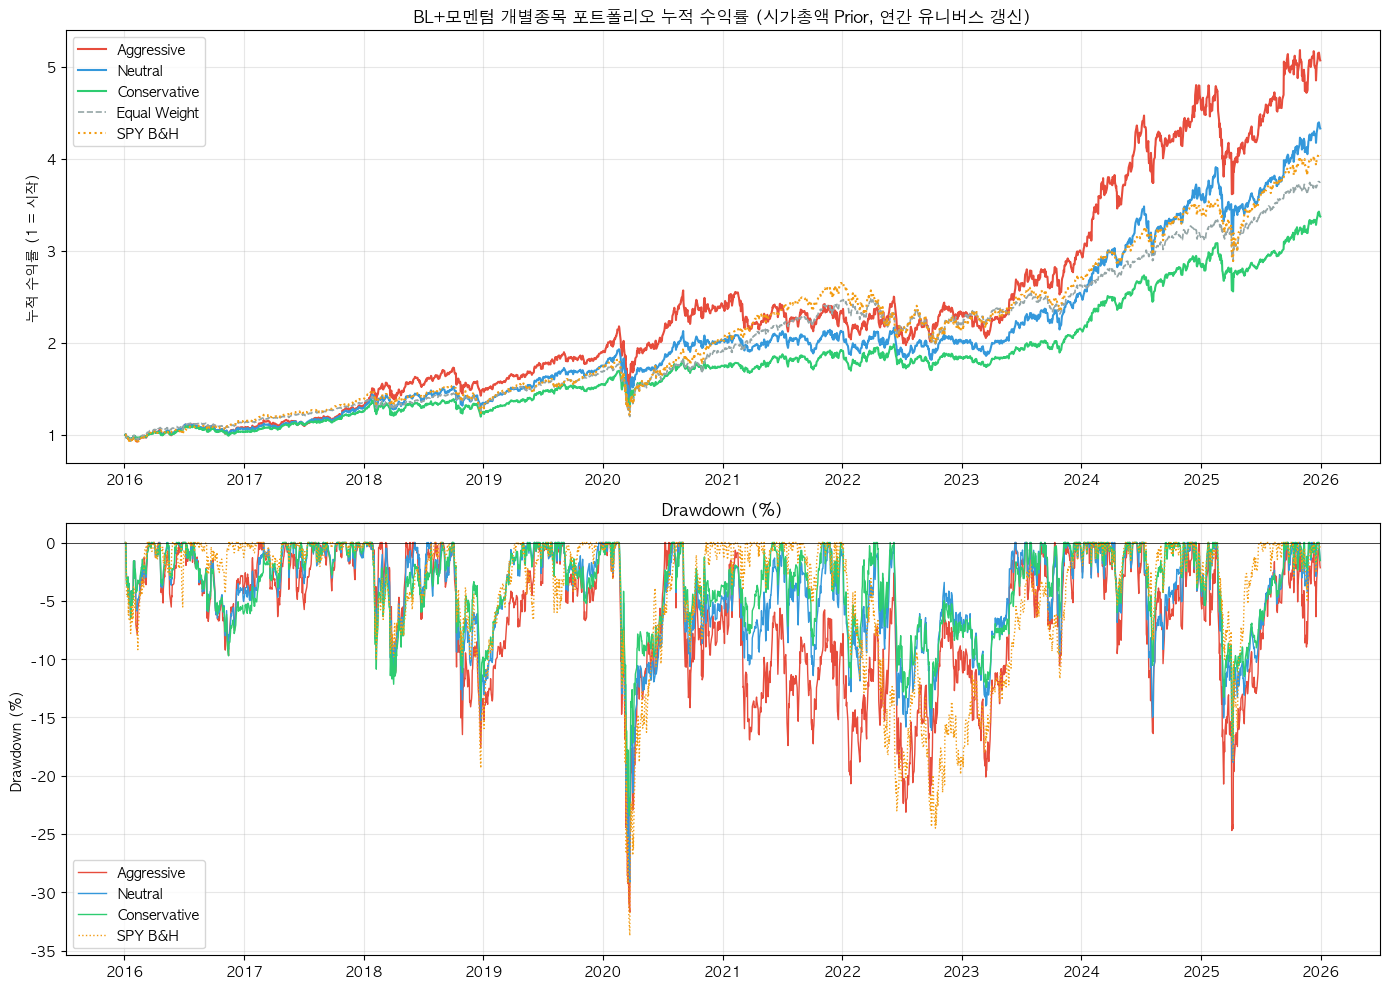

저장: images/step5_01_stocks_cumulative.png


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

COLORS = {
    'Aggressive': '#e74c3c',
    'Neutral': '#3498db',
    'Conservative': '#2ecc71',
    'EqualWeight': '#95a5a6',
    'SPY_BnH': '#f39c12'
}

# ── 누적 수익률 ──────────────────────────────────
ax = axes[0]
for p in PROFILES:
    ax.plot(dates, port_values[p], label=p, color=COLORS[p], linewidth=1.5)
ax.plot(dates, port_values['EqualWeight'],
        label='Equal Weight', color=COLORS['EqualWeight'], linewidth=1.2, linestyle='--')

spy_dates = list(spy_aligned.index)
ax.plot(spy_dates, spy_norm, label='SPY B&H', color=COLORS['SPY_BnH'], linewidth=1.5, linestyle=':')

ax.set_title('BL+모멘텀 개별종목 포트폴리오 누적 수익률 (시가총액 Prior, 연간 유니버스 갱신)',
             fontsize=12)
ax.set_ylabel('누적 수익률 (1 = 시작)')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Drawdown ─────────────────────────────────────
ax2 = axes[1]
for p in PROFILES:
    vals = np.array(port_values[p])
    running_max = np.maximum.accumulate(vals)
    dd = (vals - running_max) / running_max * 100
    ax2.plot(dates, dd, label=p, color=COLORS[p], linewidth=1)

spy_vals = spy_norm
spy_rmax = np.maximum.accumulate(spy_vals)
spy_dd = (spy_vals - spy_rmax) / spy_rmax * 100
ax2.plot(spy_dates, spy_dd, label='SPY B&H', color=COLORS['SPY_BnH'], linestyle=':', linewidth=1)

ax2.set_title('Drawdown (%)')
ax2.set_ylabel('Drawdown (%)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / 'step5_01_stocks_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5_01_stocks_cumulative.png')

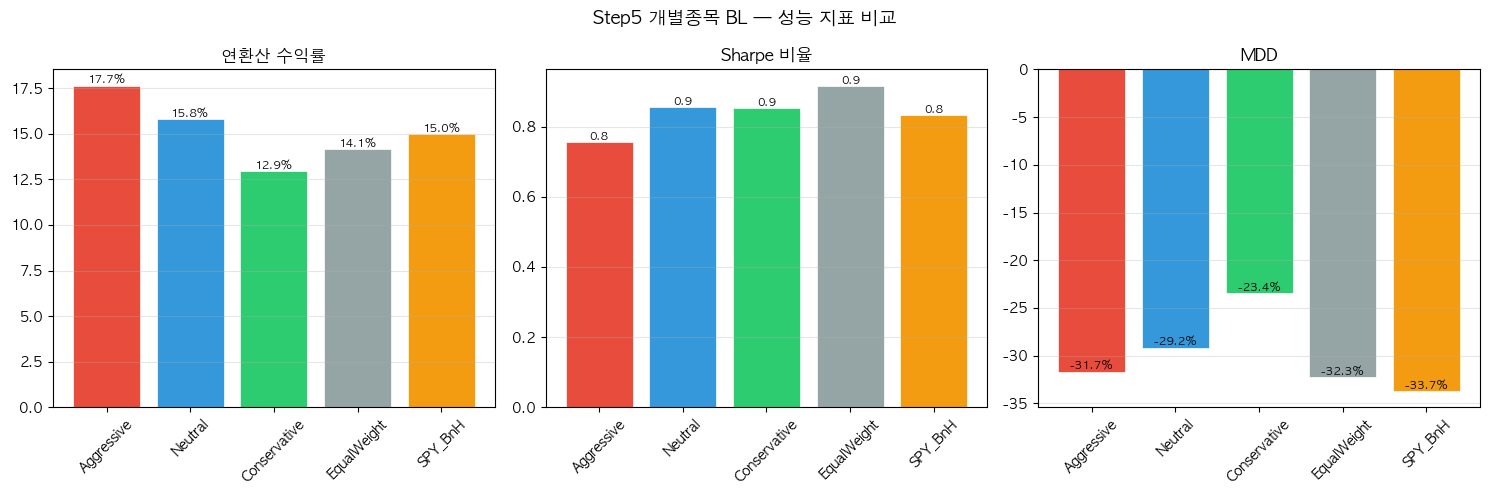

저장: images/step5_02_stocks_metrics.png


In [30]:
# 성능 지표 바차트
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(metrics.keys())
colors_list = [COLORS.get(n, '#7f8c8d') for n in names]

for ax, metric, title, fmt in zip(
    axes,
    ['ann_return', 'sharpe', 'mdd'],
    ['연환산 수익률', 'Sharpe 비율', 'MDD'],
    ['percent', 'float', 'percent']
):
    vals_plot = [metrics[n][metric] * (100 if fmt == 'percent' else 1) for n in names]
    bars = ax.bar(names, vals_plot, color=colors_list, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    unit = '%' if fmt == 'percent' else ''
    for bar, v in zip(bars, vals_plot):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.1f}{unit}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Step5 개별종목 BL — 성능 지표 비교', fontsize=13)
plt.tight_layout()
plt.savefig(IMAGES / 'step5_02_stocks_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5_02_stocks_metrics.png')